# Sample-Optimal Estimation of the Fréchet Inception Distance

This notebook reconstructs **11 figures and 13 empirical tables** from the
bundled trial records, including development-set strategy selection. Each
result has its own cell, arranged in manuscript order.

To refresh everything, select **Run All Cells**. Install the CPU reporting
requirements and the `notebook` extra as described in the repository README.
The notebook and command-line report share their calculation and rendering functions.

## Load the reproduction functions

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").is_file():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

from IPython.display import HTML, Image, display
from reproduce.__main__ import reproduce

OUTPUT = Path("outputs/paper")


def show_figure(stem):
    display(Image(filename=str(OUTPUT / "figures" / f"{stem}.png")))


def show_table(stem):
    display(HTML((OUTPUT / "tables" / f"{stem}.html").read_text(encoding="utf-8")))

## Recompute the report

Read the bundled records, aggregate within and across cases, select VALE strategies on development data, and write the figures and tables.

In [2]:
%%capture
tables = reproduce(OUTPUT)

## Introduction

### Figure 1: Gaussian and ImageNet comparison

Gaussian absolute error at 50K samples and raw Inception FID estimates for DDO/EDM2-L-512. FID∞ and VALE₂ share 15 sample sizes uniformly spaced from 5K to N.

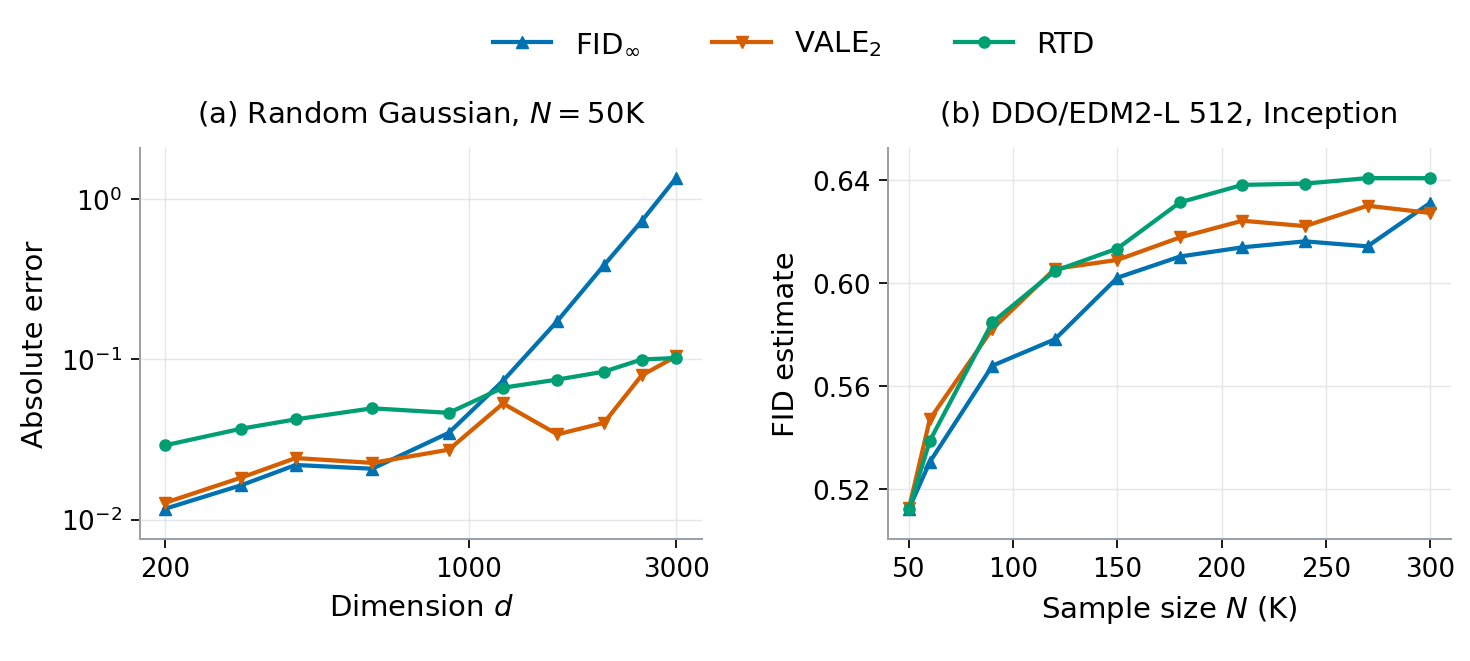

In [3]:
show_figure("intro_gaussian_and_imagenet")

## Gaussian experiments

The dimension and stress figures use the median absolute error over five trials within each covariance pair, followed by the mean and sample SD across ten pairs.

### Table 2: Isotropic experiment

Mean estimate, signed error, and trial SD over 50 trajectories, with target squared distance 5.

In [4]:
show_table("isotropic")

,Empirical,OLS1,OLS2,OLS3,RTD
Mean estimate,37.8610,-9.1300,6.9197,4.7519,4.9033
Signed error,32.8610,-14.1300,1.9197,-0.2481,-0.0967
Standard Deviation,0.0139,0.0316,0.0290,0.0447,0.1164


### Figure 2: Haar log-uniform dimension sweep

Estimation error across dimensions at four sample budgets, with dimension-scaling reference lines.

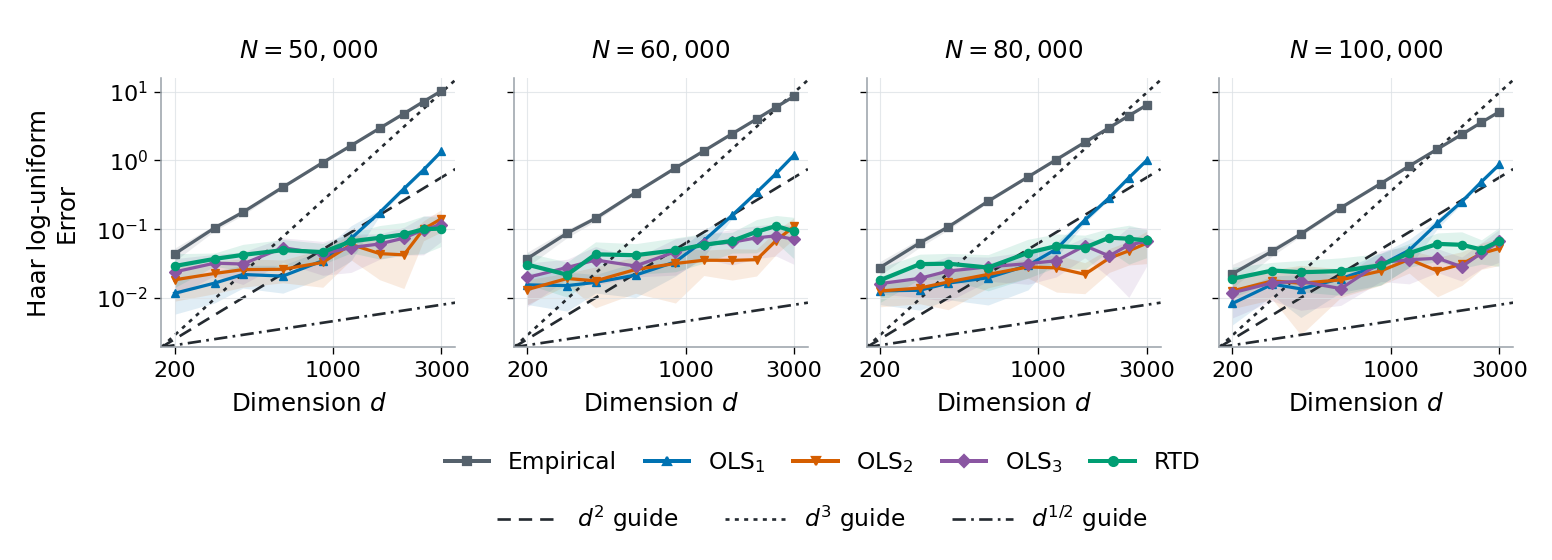

In [5]:
show_figure("gaussian_dimension_haar")

## ImageNet experiments

### Figure 3: StyleGAN-XL-256 proxy estimates

Empirical, FID∞, and RTD estimates from 30K to 300K samples for Inception, DINOv2, and CLIP. FID∞ and RTD curves report medians of five estimates.

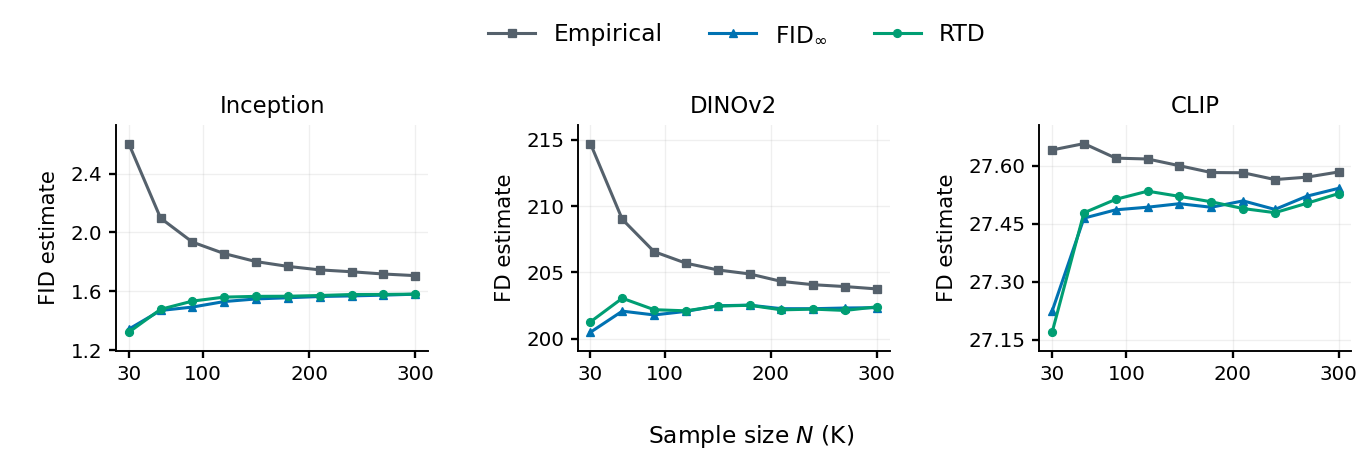

In [6]:
show_figure("imagenet_proxy_example")

### Table 3: Held-out utility and proxy sensitivity

Median absolute error over five held-out trials per generator, followed by the mean and sample SD across seven generators, against each of three proxies.

In [7]:
show_table("proxy_sensitivity")

Embedding,Estimator,Empirical proxy,FID∞ proxy,RTD proxy
Inception,Empirical,0.5108 ± 0.0264,0.6389 ± 0.0267,0.6287 ± 0.0268
,FID∞,0.2531 ± 0.0456,0.1250 ± 0.0423,0.1352 ± 0.0471
,VALE1,0.2410 ± 0.0406,0.1129 ± 0.0369,0.1231 ± 0.0412
,VALE2,0.2224 ± 0.0372,0.0944 ± 0.0347,0.1046 ± 0.0356
,VALE3,0.2328 ± 0.0383,0.1048 ± 0.0345,0.1150 ± 0.0376
,RTD,0.1972 ± 0.0422,0.0692 ± 0.0418,0.0794 ± 0.0416
DINOv2,Empirical,5.5063 ± 0.2975,6.9704 ± 0.3749,6.9433 ± 0.2378
,FID∞,3.0186 ± 0.3095,1.5545 ± 0.3459,1.5816 ± 0.3008
,VALE1,2.9861 ± 0.3162,1.5220 ± 0.3335,1.5492 ± 0.2806
,VALE2,2.6939 ± 0.4000,1.2409 ± 0.3962,1.2570 ± 0.3987


### Table 4: Successive extrapolation ablations

Mean RMSE over seven generators and orders 1–3; percentage reductions compare consecutive configurations.

In [8]:
show_table("ablation_summary")

Configuration,Inception,DINOv2,CLIP
"FID∞, OLS2, OLS3",0.0468,1.0702,0.1121
+ VALE weighting,0.0346 (↓26.1%),0.8696 (↓18.7%),0.0930 (↓17.0%)
+ Regression strategy optimization,0.0308 (↓11.2%),0.7679 (↓11.7%),0.0878 (↓5.6%)


### Table 5: Computation time

Mean and sample SD of 35 recorded runtimes per method and embedding, in milliseconds.

In [9]:
show_table("runtime")

Embedding,Empirical,FID∞,VALE1,VALE2,VALE3,RTD
Inception,64.9 ± 0.2,915.3 ± 3.0,123.1 ± 0.3,890.2 ± 2.1,1181.1 ± 3.6,1976.7 ± 5.3
DINOv2,25.9 ± 0.1,368.8 ± 1.1,50.3 ± 0.3,358.9 ± 1.1,478.0 ± 1.5,559.3 ± 2.0
CLIP,19.2 ± 0.1,272.6 ± 1.8,262.8 ± 2.4,354.9 ± 7.7,362.3 ± 2.4,217.7 ± 12.2


### Table 6: Inception sample budgets

Held-out error against the RTD proxy from 10K to 50K samples. The 50K endpoint uses the same measurements as Table 3.

In [10]:
show_table("sample_budget")

N,Empirical,FID∞,VALE1,VALE2,VALE3,RTD
10K,3.588 ± 0.134,0.211 ± 0.058,0.223 ± 0.073,0.137 ± 0.053,1.014 ± 0.579,101.592 ± 23.510
20K,1.724 ± 0.060,0.159 ± 0.054,0.153 ± 0.048,0.107 ± 0.053,0.172 ± 0.067,0.490 ± 0.119
30K,1.107 ± 0.032,0.144 ± 0.030,0.137 ± 0.028,0.108 ± 0.050,0.100 ± 0.046,0.149 ± 0.059
40K,0.804 ± 0.026,0.141 ± 0.033,0.130 ± 0.033,0.112 ± 0.040,0.123 ± 0.038,0.118 ± 0.044
50K,0.629 ± 0.027,0.135 ± 0.047,0.123 ± 0.041,0.105 ± 0.036,0.115 ± 0.038,0.079 ± 0.042


## Additional Gaussian experiments

### Figure 4: Spiked-bulk dimension sweep

Estimation error across dimensions at four fixed sample budgets.

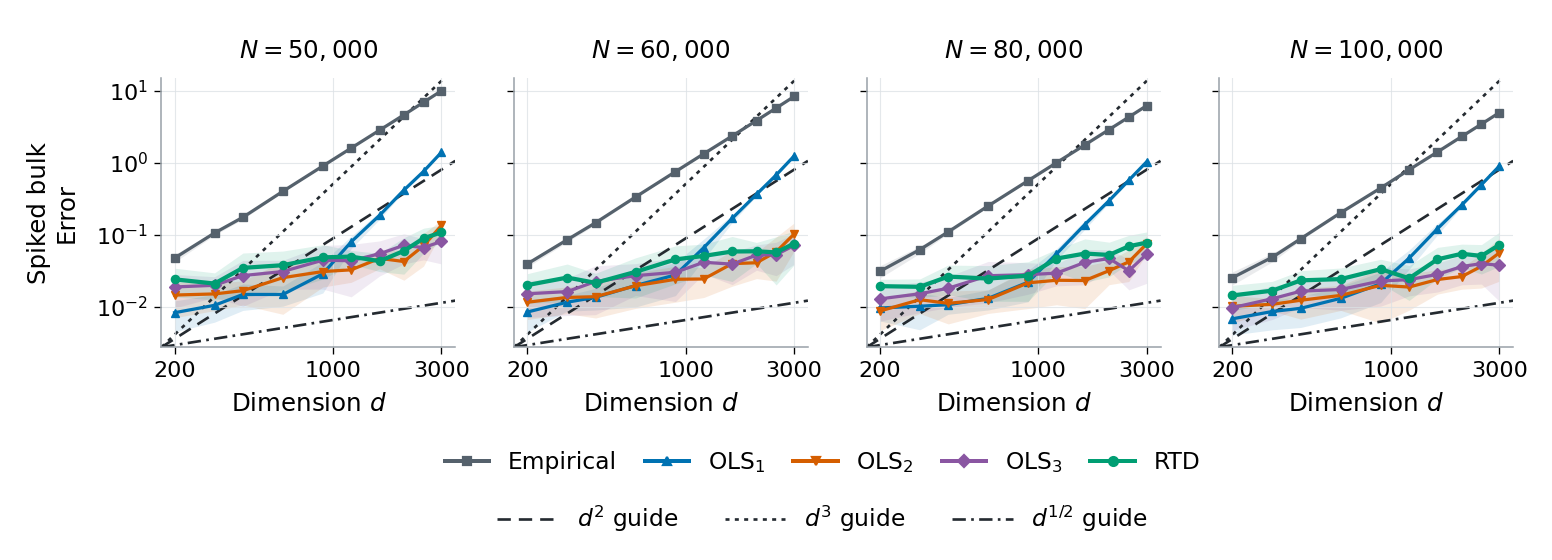

In [11]:
show_figure("gaussian_dimension_spiked_bulk")

### Figure 5: Rotated Toeplitz dimension sweep

Estimation error across dimensions at four fixed sample budgets.

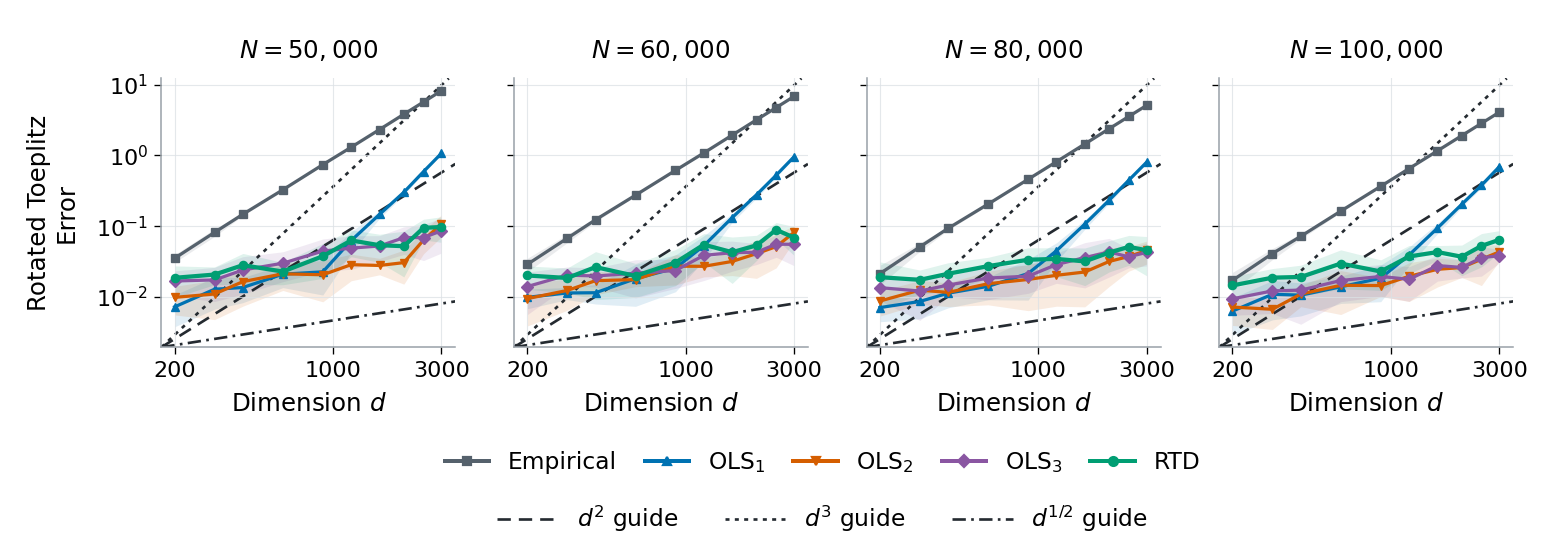

In [12]:
show_figure("gaussian_dimension_rotated_toeplitz")

### Figure 6: Rank-deficient stress test

Estimation error for three rank fractions, with population squared distance 5.

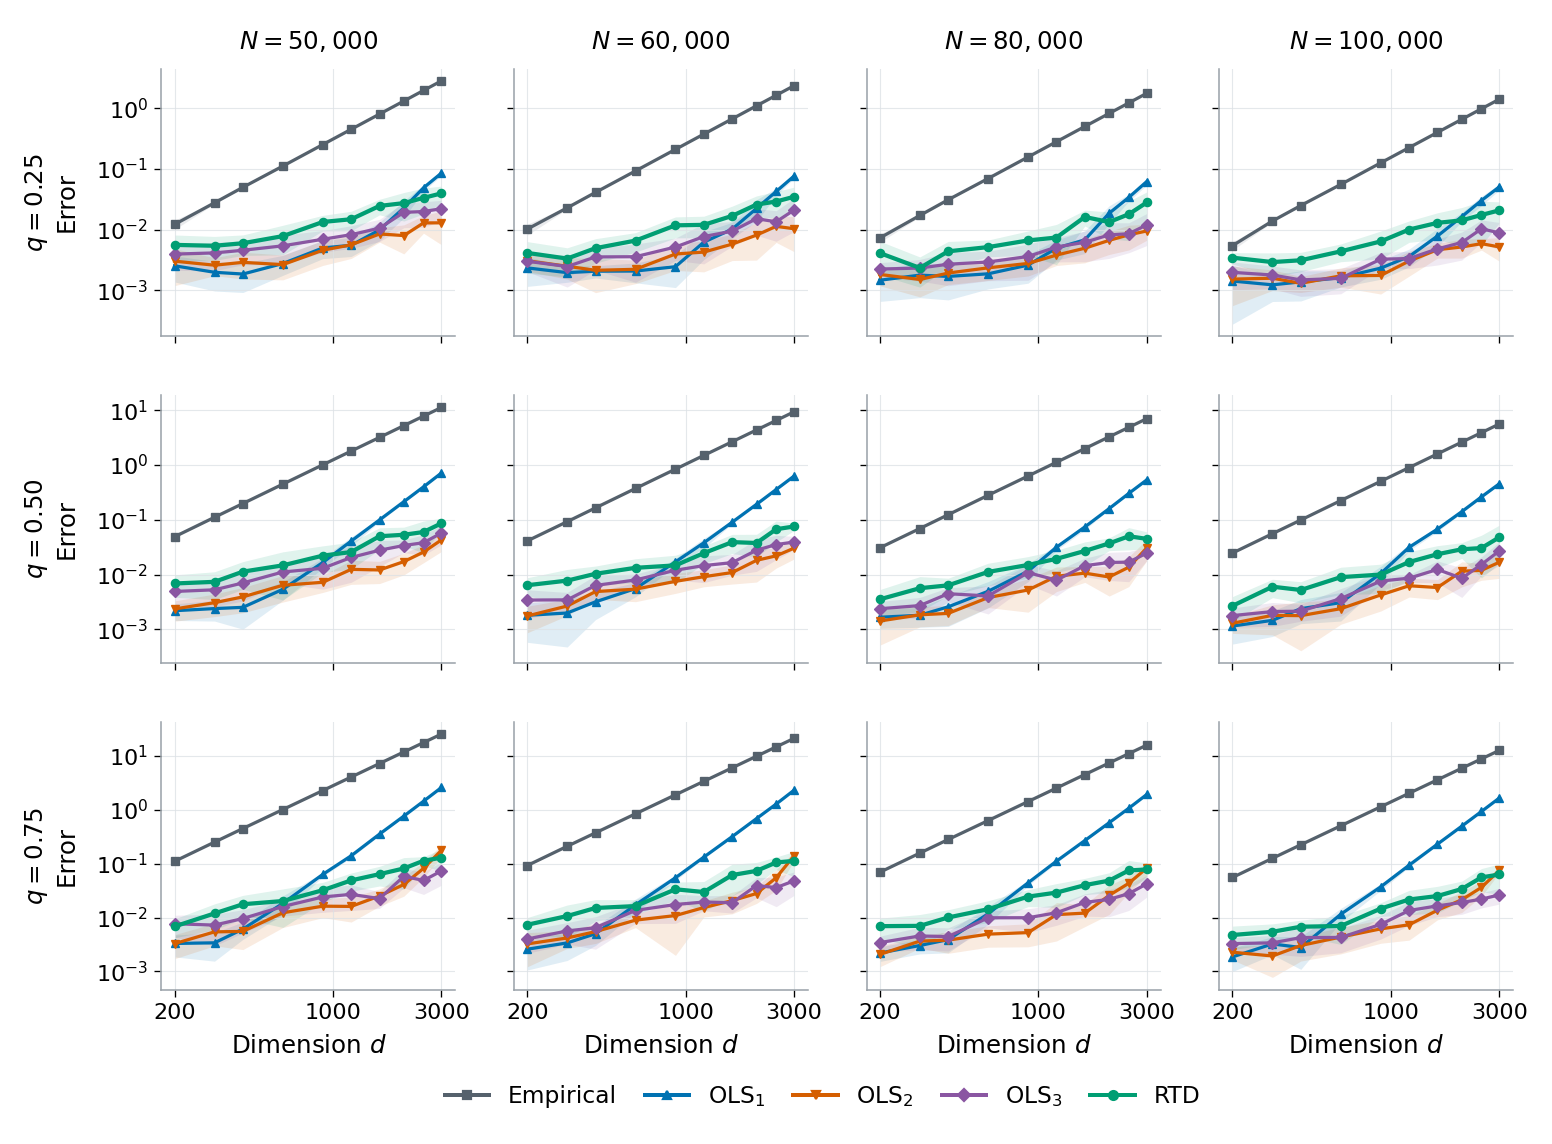

In [13]:
show_figure("gaussian_rank_error")

### Figure 7: Ill-conditioned stress test

Estimation error for three condition numbers, with population squared distance 5.

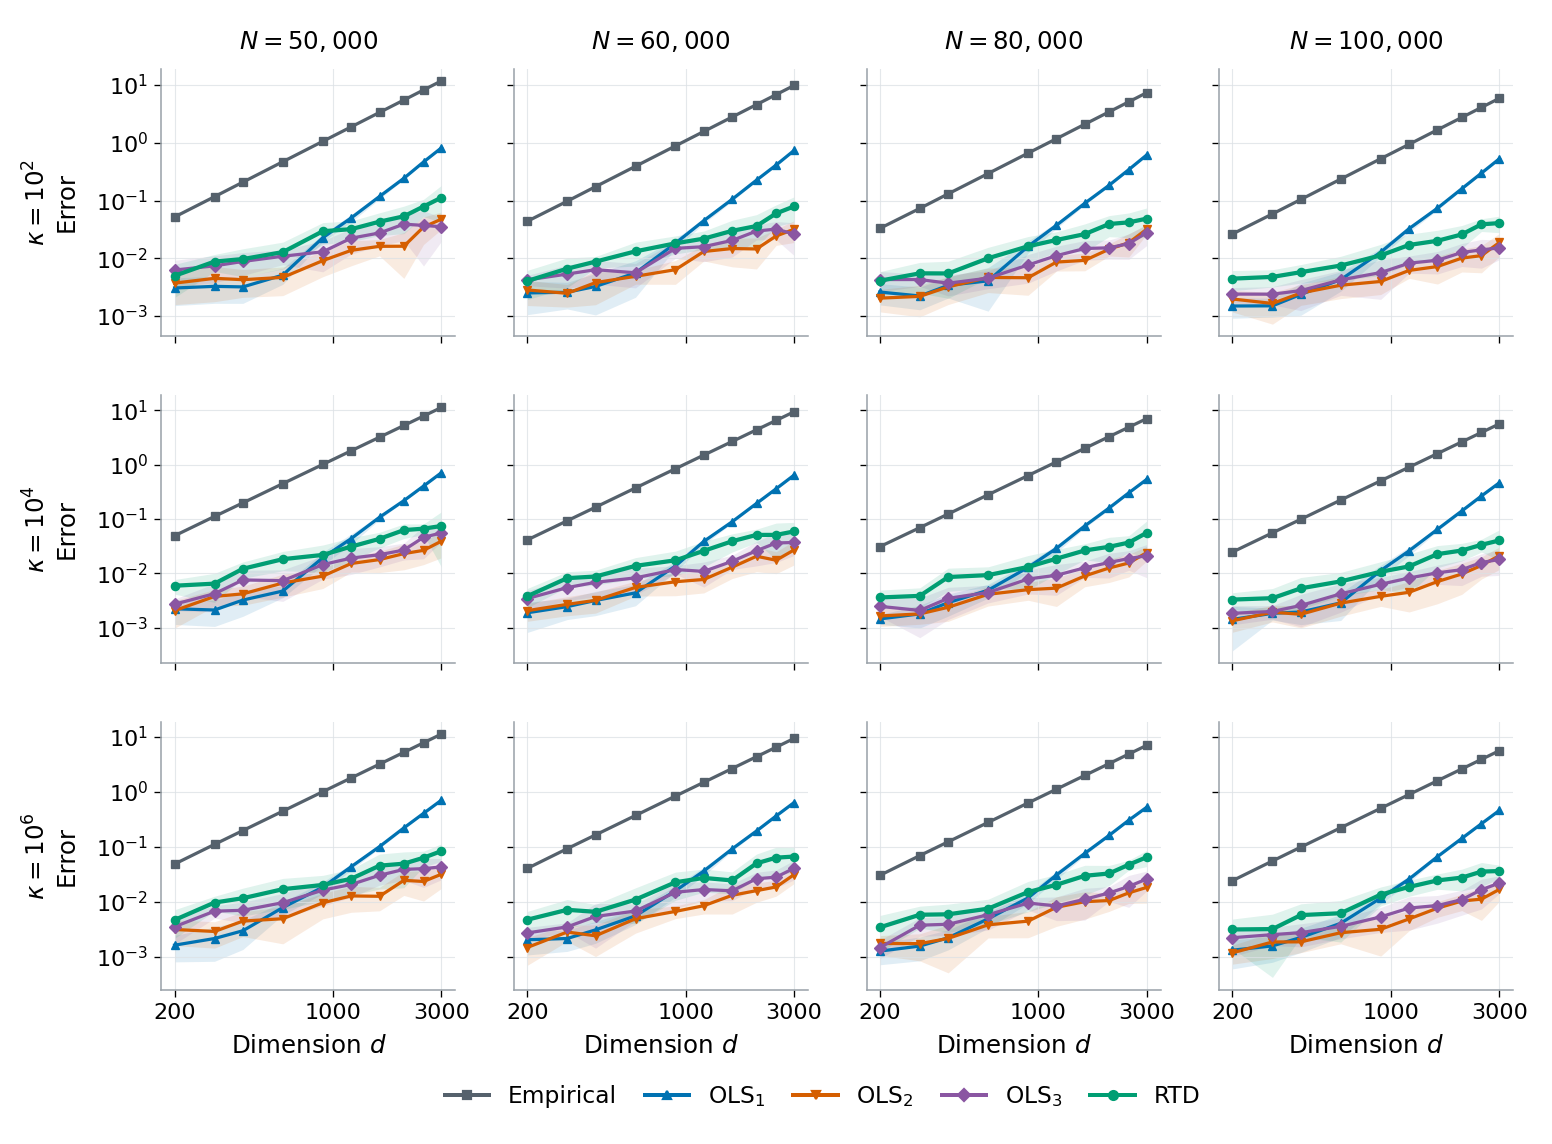

In [14]:
show_figure("gaussian_condition_error")

## Additional ImageNet results

### Table 8: Model checkpoints and proxies

Full-300K RTD proxy values and checkpoint reference information.

In [15]:
show_table("checkpoint_proxies")

Model,Resolution,Inception Qc,DINOv2 Qc,CLIP Qc,Published FID
StyleGAN-XL,64,1.936,206.696,9.852,1.51
DDO/EDM2-S,64,0.333,63.356,3.270,0.97
StyleGAN-XL,256,1.581,202.413,27.528,2.30
VAR-d30,256,1.127,65.289,19.089,1.73
StyleGAN-XL,512,1.748,210.961,30.260,2.41
DDO/EDM2-L,512,0.641,39.898,9.402,1.21
VAR-d36,512,1.957,53.301,13.780,2.63


### Table 9: Proxy agreement

Mean absolute differences from RTD at the same sample budget across seven generators.

In [16]:
show_table("proxy_agreement")

Estimator,N,Inception,DINOv2,CLIP
FID∞,30K,0.0439,0.7538,0.0278
FID∞,300K,0.0102,0.1334,0.0082
Empirical,300K,0.1178,1.4370,0.0405


### Figure 8: Additional Inception proxy curves

Estimates from 30K to 300K for the six generators supplementing Figure 3.

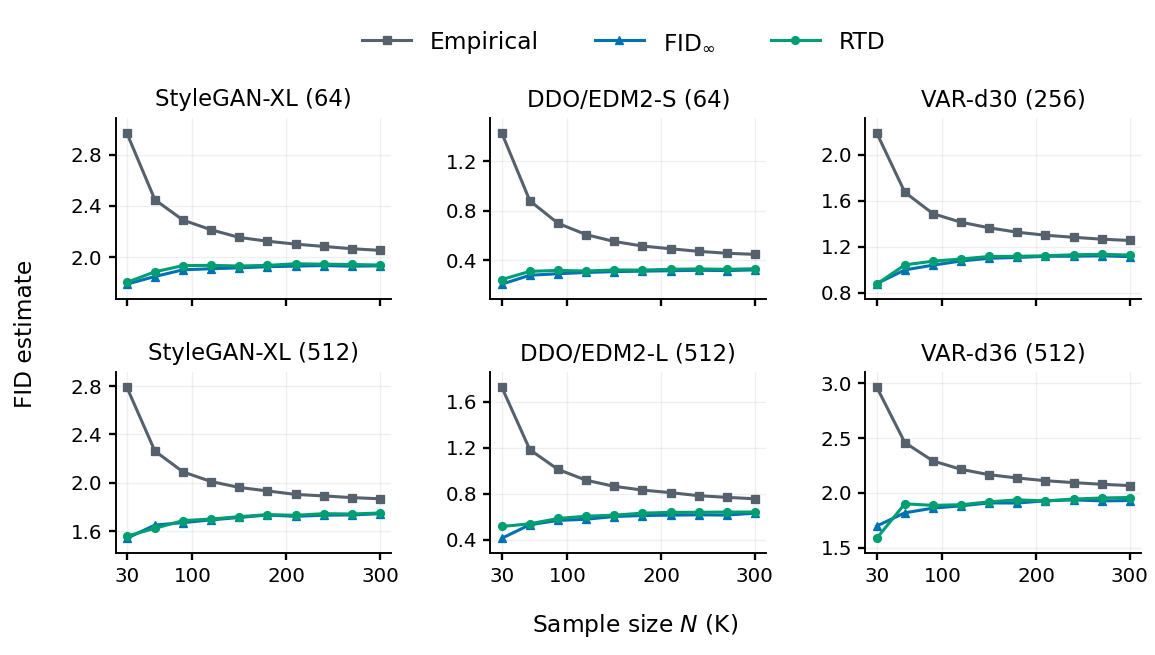

In [17]:
show_figure("imagenet_proxy_consistency_inception_additional")

### Figure 9: Additional DINOv2 proxy curves

The same six generators and sample budgets using DINOv2 features.

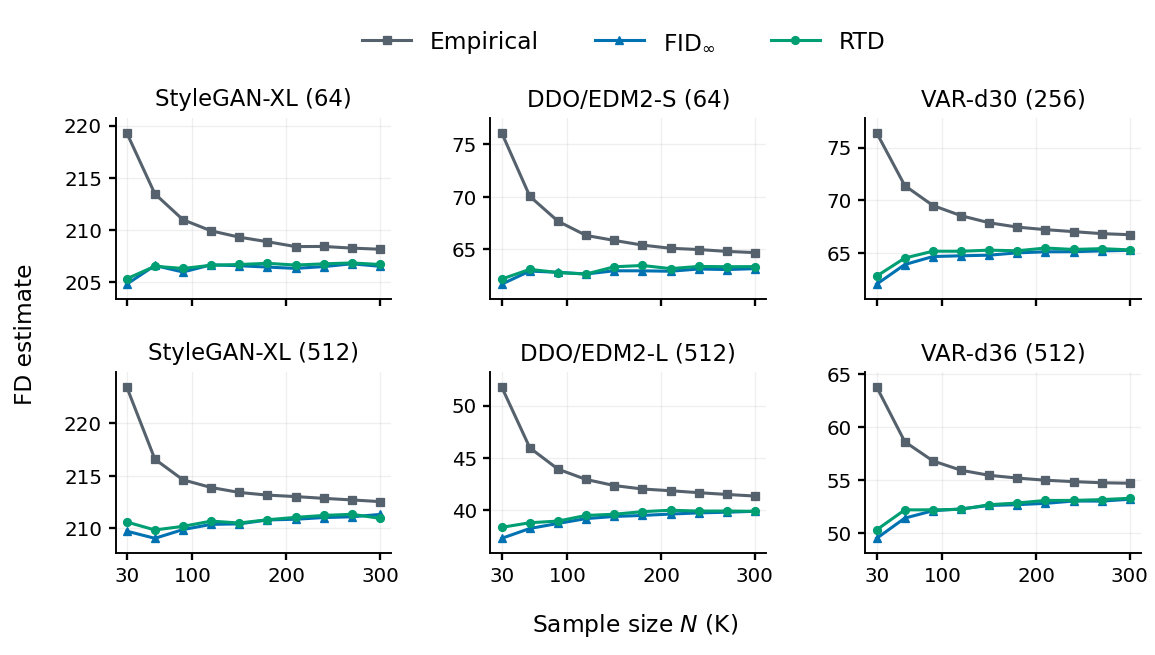

In [18]:
show_figure("imagenet_proxy_consistency_dinov2_additional")

### Figure 10: Additional CLIP proxy curves

The same six generators and sample budgets using CLIP features.

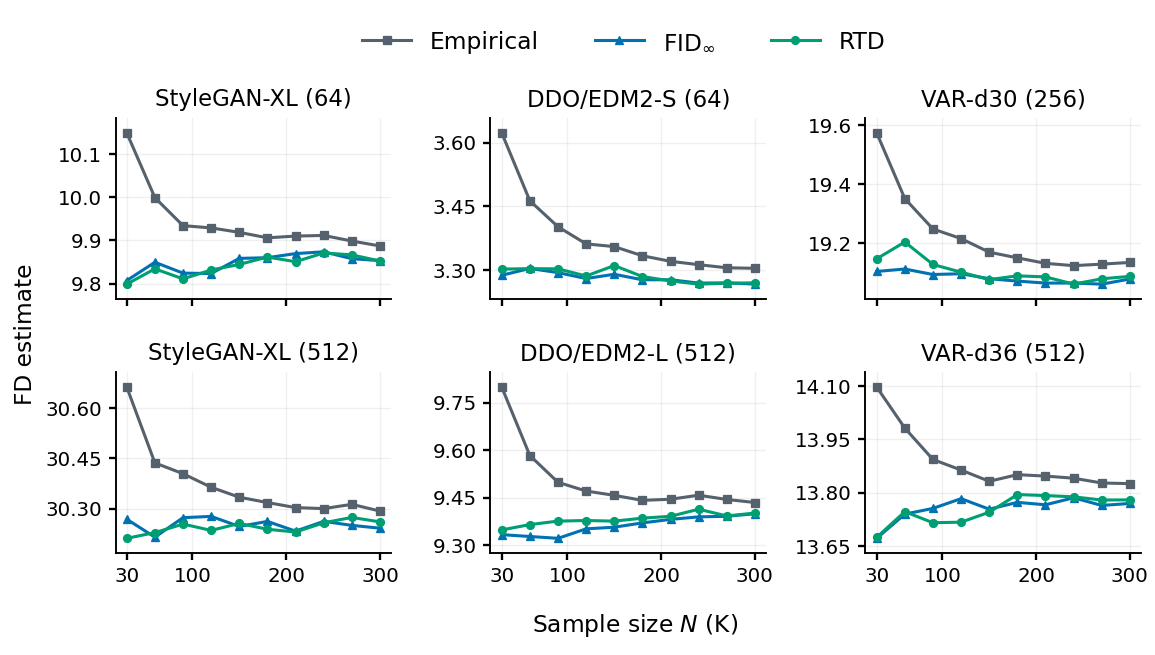

In [19]:
show_figure("imagenet_proxy_consistency_clip_additional")

### Figure 11: Polynomial order

OLS center error, trial SD, and RMSE through order six. Hollow markers show generators; solid curves show their means.

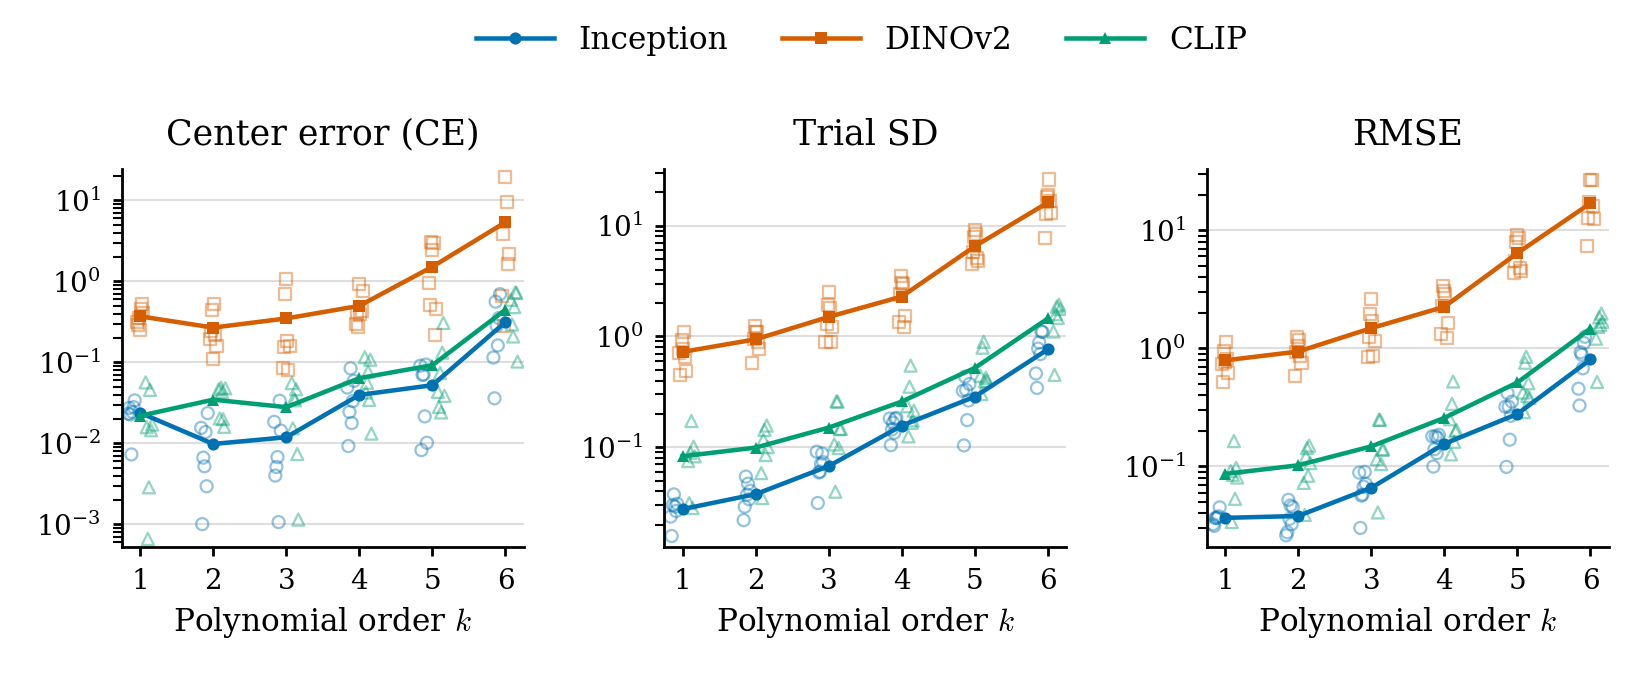

In [20]:
show_figure("imagenet_ols_order_rtd_absolute")

### Table 10: OLS versus VALE

Matched orders one to four, using the same nodes for ordinary and variance-aware regression.

In [21]:
show_table("matched_ols_va")

Embedding,Order k,OLSk SD,VALEk SD,OLSk RMSE,VALEk RMSE,RMSE drop (%),Win rate
Inception,1,0.0277 ± 0.0068,0.0233 ± 0.0065,0.0366 ± 0.0044,0.0289 ± 0.0048,21.21,7/7
,2,0.0378 ± 0.0109,0.0289 ± 0.0092,0.0380 ± 0.0101,0.0291 ± 0.0081,23.48,7/7
,3,0.0678 ± 0.0202,0.0469 ± 0.0115,0.0659 ± 0.0206,0.0458 ± 0.0115,28.62,7/7
,4,0.1569 ± 0.0301,0.1224 ± 0.0227,0.1553 ± 0.0328,0.1212 ± 0.0240,21.71,7/7
DINOv2,1,0.7256 ± 0.2274,0.6771 ± 0.1986,0.7901 ± 0.2031,0.6994 ± 0.1968,11.34,6/7
,2,0.9416 ± 0.2215,0.7628 ± 0.1987,0.9390 ± 0.2329,0.7707 ± 0.2157,18.29,7/7
,3,1.5010 ± 0.5945,1.1414 ± 0.4880,1.4816 ± 0.6439,1.1388 ± 0.5456,23.87,7/7
,4,2.2905 ± 0.9358,1.7048 ± 0.7726,2.2480 ± 0.8685,1.6848 ± 0.7001,25.59,7/7
CLIP,1,0.0830 ± 0.0485,0.0757 ± 0.0425,0.0863 ± 0.0409,0.0790 ± 0.0363,8.24,6/7
,2,0.0995 ± 0.0440,0.0805 ± 0.0361,0.1021 ± 0.0399,0.0838 ± 0.0323,17.64,7/7


### Table 11: Selected VALE schedules

Schedules selected on development data by mean case RMSE for each embedding and order.

In [22]:
show_table("selected_strategies")

Embedding,Order k,Schedule,Points ℓ,RMSE
Inception,1,Endpoints,2,0.0275 ± 0.0045
,2,Chebyshev in 1/n,15,0.0254 ± 0.0079
,3,Chebyshev in 1/n,20,0.0393 ± 0.0111
DINOv2,1,Endpoints,2,0.6675 ± 0.1947
,2,Chebyshev in 1/n,15,0.6871 ± 0.1925
,3,Chebyshev in 1/n,20,0.9491 ± 0.3099
CLIP,1,Uniform in 1/n,15,0.0742 ± 0.0360
,2,Uniform in 1/n,20,0.0791 ± 0.0350
,3,Uniform in n,20,0.1101 ± 0.0376


### Table 12: Inception regression-point ablation

Mean case RMSE and between-generator SD for each schedule and point count.

In [23]:
show_table("va_grid_fid")

Order k,Points ℓ,Uniform n,Uniform 1/n,Chebyshev 1/n
1,2,0.0275 ± 0.0045,0.0275 ± 0.0045,0.0275 ± 0.0045
1,10,0.0291 ± 0.0060,0.0324 ± 0.0049,0.0317 ± 0.0058
1,15,0.0289 ± 0.0048,0.0336 ± 0.0078,0.0327 ± 0.0042
1,20,0.0279 ± 0.0057,0.0340 ± 0.0065,0.0309 ± 0.0035
2,3,0.0415 ± 0.0171,0.0371 ± 0.0083,0.0371 ± 0.0083
2,10,0.0324 ± 0.0115,0.0307 ± 0.0090,0.0323 ± 0.0115
2,15,0.0291 ± 0.0081,0.0310 ± 0.0091,0.0254 ± 0.0079
2,20,0.0280 ± 0.0088,0.0289 ± 0.0076,0.0287 ± 0.0095
3,4,0.1149 ± 0.0361,0.0893 ± 0.0241,0.0697 ± 0.0217
3,10,0.0573 ± 0.0108,0.0519 ± 0.0115,0.0553 ± 0.0161


### Table 13: DINOv2 regression-point ablation

The same regression grid for DINOv2.

In [24]:
show_table("va_grid_fd_dinov2")

Order k,Points ℓ,Uniform n,Uniform 1/n,Chebyshev 1/n
1,2,0.6675 ± 0.1947,0.6675 ± 0.1947,0.6675 ± 0.1947
1,10,0.7062 ± 0.2072,0.7179 ± 0.2516,0.7403 ± 0.2734
1,15,0.6994 ± 0.1968,0.7498 ± 0.1934,0.7276 ± 0.2032
1,20,0.7186 ± 0.2074,0.7277 ± 0.1825,0.6941 ± 0.1803
2,3,0.9551 ± 0.4135,0.9665 ± 0.2765,0.9665 ± 0.2765
2,10,0.8848 ± 0.1940,0.8011 ± 0.2110,0.8931 ± 0.2122
2,15,0.7707 ± 0.2157,0.8699 ± 0.2057,0.6871 ± 0.1925
2,20,0.8050 ± 0.2533,0.7990 ± 0.3580,0.6903 ± 0.2252
3,4,2.3145 ± 0.5352,1.8733 ± 0.5067,1.3758 ± 0.4335
3,10,1.0432 ± 0.2702,1.1186 ± 0.4467,1.1959 ± 0.5001


### Table 14: CLIP regression-point ablation

The same regression grid for CLIP.

In [25]:
show_table("va_grid_clip")

Order k,Points ℓ,Uniform n,Uniform 1/n,Chebyshev 1/n
1,2,0.0772 ± 0.0333,0.0772 ± 0.0333,0.0772 ± 0.0333
1,10,0.0805 ± 0.0309,0.0785 ± 0.0382,0.0798 ± 0.0333
1,15,0.0790 ± 0.0363,0.0742 ± 0.0360,0.0786 ± 0.0318
1,20,0.0790 ± 0.0362,0.0797 ± 0.0373,0.0780 ± 0.0349
2,3,0.1129 ± 0.0500,0.0983 ± 0.0361,0.0983 ± 0.0361
2,10,0.1025 ± 0.0457,0.0927 ± 0.0329,0.0918 ± 0.0306
2,15,0.0838 ± 0.0323,0.0936 ± 0.0426,0.0829 ± 0.0268
2,20,0.0857 ± 0.0325,0.0791 ± 0.0350,0.0817 ± 0.0367
3,4,0.3055 ± 0.1352,0.2116 ± 0.0934,0.1450 ± 0.0703
3,10,0.1244 ± 0.0826,0.1147 ± 0.0402,0.1207 ± 0.0593


### Table 15: DINOv2 and CLIP sample budgets

Held-out error against the RTD proxy from 10K to 50K samples, using the same statistic as Table 6.

In [26]:
show_table("sample_budget_additional")

## Exported results

`outputs/paper/figures` contains PDF and PNG figures. `outputs/paper/tables`
contains HTML and LaTeX tables plus full-precision CSV records.
`outputs/paper/analysis` contains case statistics and selected configurations.

For independent checks against the manuscript and archived plug-in nodes, run
`python -m pytest tests/test_reproduction.py -q` from the repository root.
See [the reproduction guide](../docs/reproduction.md) for reporting definitions and data sources.